In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv('../data/raw/grades.csv', sep = ';')
df.head()

/tmp/ipykernel_86885/275332544.py:1: DtypeWarning: Columns (0: course, 1: module, 2: academic_year) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/grades.csv', sep = ';')


,student_id_hash,campus,faculty,program,education_level,course,group,place_type,subject_name,exam_type,subject_unit,grade_10,absence_status,module,academic_year,student_status
0,657b2a6069af97615b4c82205863561b,Москва,факультет экономических наук,Финансовый инжиниринг,Магистратура,2,МФИИН231,Коммерческие,Дисциплина: Финансовые рынки: проблемы и решения,Первая сдача,М_ФРПИР_П_676572_1,6,\N,1,2024,graduated
1,394b76e0ea7739201d39f8c139808de3,Москва,Высшая школа бизнеса,Управление бизнесом,Бакалавриат,4,БМБ2102,Коммерческие,Дисциплина: Управление организационной жизнестойкостью,Первая сдача,М_УОЖ_Г_909498_2,7,\N,1,2024,graduated
2,a6b5e298d01156513fec7056f21313c5,Москва,факультет права,Юрист в правосудии,Магистратура,2,МЮП231,Бюджетные,Дисциплина: Отбор и назначение судей,Первая сдача,М_ОИНС_Г_800881_1,8,\N,1,2024,graduated
3,592333b03350965546a17ae33cd4d3d8,Москва,факультет права,Юрист в бизнесе,Магистратура,2,МЮБ232,Коммерческие,Дисциплина: Экономический анализ права,Первая сдача,М_ЭАП_П_787475_1,8,\N,1,2024,graduated
4,871132d017f31ba4bf97371ac228c638,Москва,факультет мировой экономики и мировой политики,Экономика окружающей среды и устойчивое развитие,Магистратура,2,МЭОС231,Коммерческие места для иностранных граждан,"Научно-исследовательский семинар: Семинар наставника ""Экономика окружающей среды и устойчивое ра...",Первая сдача,М_СНЭОСИУР_Г_735356_1,5,\N,1,2024,graduated


>Проблема: \N вместо Nan, в случае присутствия студента -- absence_status = \N

In [6]:
print(df.info())
print(len(df))


<class 'pandas.DataFrame'>
RangeIndex: 1767986 entries, 0 to 1767985
Data columns (total 16 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   student_id_hash  str   
 1   campus           str   
 2   faculty          str   
 3   program          str   
 4   education_level  str   
 5   course           object
 6   group            str   
 7   place_type       str   
 8   subject_name     str   
 9   exam_type        str   
 10  subject_unit     str   
 11  grade_10         str   
 12  absence_status   str   
 13  module           object
 14  academic_year    object
 15  student_status   str   
dtypes: object(3), str(13)
memory usage: 215.8+ MB
None
1767986


In [7]:
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 200)

table = []
for column in df.columns[1:]:
    table.append(df[column].unique())

table_df = pd.DataFrame({
    'columns' : df.columns[1:],
    'unique values' : table
})

table_df

,columns,unique values
0,campus,"[Москва, НИУ ВШЭ - Нижний Новгород, НИУ ВШЭ - Пермь, НИУ ВШЭ - Санкт-Петербург, \N]"
1,faculty,"[факультет экономических наук, Высшая школа бизнеса, факультет права, факультет мировой экономик..."
2,program,"[Финансовый инжиниринг, Управление бизнесом, Юрист в правосудии, Юрист в бизнесе, Экономика окру..."
3,education_level,"[Магистратура, Бакалавриат, Специалитет]"
4,course,"[2, 4, 3, 5, 6, 1, 2, 4, 3, 1, 5, 6, \N]"
5,group,"[МФИИН231, БМБ2102, МЮП231, МЮБ232, МЭОС231, ММД231, МИНЯЗ231, МДРОБ232, СМК233, ММРЭК231, МУЛЦТ..."
6,place_type,"[Коммерческие, Бюджетные, Коммерческие места для иностранных граждан, По межправительственным со..."
7,subject_name,"[Дисциплина: Финансовые рынки: проблемы и решения, Дисциплина: Управление организационной жизнес..."
8,exam_type,"[Первая сдача, Пересдача, Полный перезачет, Пересдача с комиссией, Пересдача по уважительной при..."
9,subject_unit,"[М_ФРПИР_П_676572_1, М_УОЖ_Г_909498_2, М_ОИНС_Г_800881_1, М_ЭАП_П_787475_1, М_СНЭОСИУР_Г_735356_..."


In [ ]:
# table_df.to_csv('data/processed/unique_values.csv', index=False, encoding='utf-8')

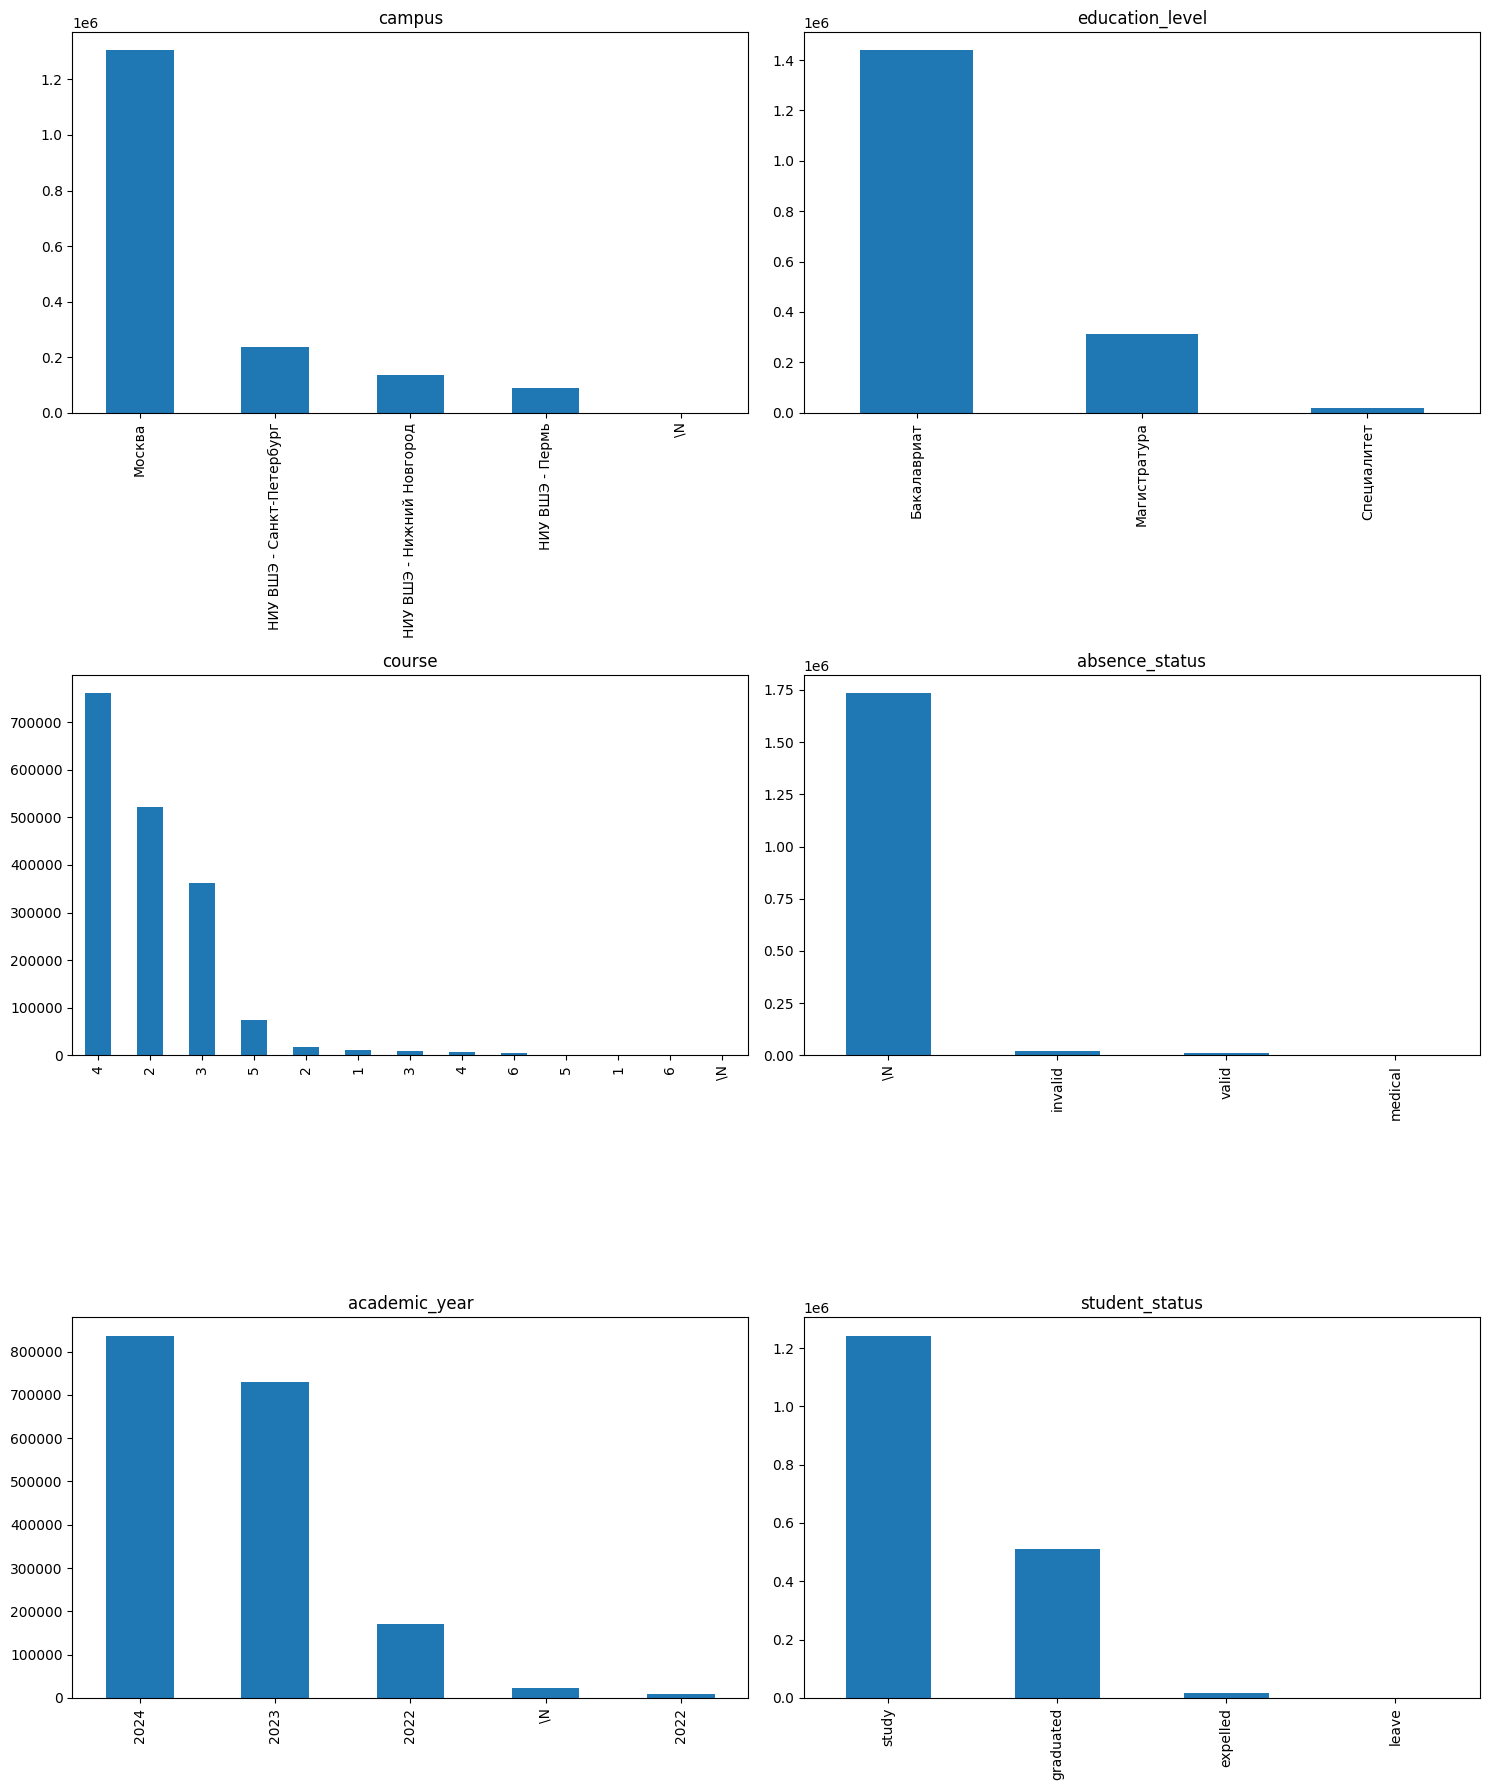

In [5]:
cols = ['campus', 'education_level', 'course', 'absence_status', 'academic_year', 'student_status']

l = len(cols)

fig, axes = plt.subplots(l//2, 2, figsize = (15, 3*l))
for i, col in enumerate(cols):
    if df[col].dtype == 'object' or df[col].dtype == 'str':
        df[col].value_counts().plot(kind ='bar', ax = axes[i//2, i%2])
    else: 
        df[col].hist(ax = axes[i//2, i%2])

    axes[i//2, i%2].set_title(col)
    axes[i//2, i%2].set_xlabel('')
plt.tight_layout()
plt.show()



        

> Проблема: некоторые колонки имеют разные значения в разных форматах, обозначающие одно и то же ( курс: число и строка)

In [9]:
students_with_multiple = df.groupby('student_id_hash')['student_status'].nunique()
result_ids = students_with_multiple[students_with_multiple > 1].index.tolist()

In [10]:
result_ids

['00356be24f5bf40925aafb68fd75e7f2',
 '0800407d79de559132f72af028d0986e',
 '233c97913a112c6f6ff26b7c32c2c1b7',
 '29153cf8ecd99a3326cadeba1cae5821',
 '391e8de671967a21bb2071695cdf9f31',
 '48a745db2d3631fd1f15e9dec3b16ebf',
 '5a145b4ab4374064089b8e772510d417',
 '5ab4665a06a3eade5249dc726b4ef3a1',
 '5f05daa0188af0dc8f639623e4f3ec1c',
 '67cee77a13863c9f7888f139a5117818',
 '71d76b7ac3652e3ccc47782a750da872',
 '7d69546389a306adca3ec2c7fa4d1ff8',
 '95a4a2a7aaa0adaa984cc56bda4a3332',
 'a66bc41034f4abd8a280052d8a4a1eba',
 'a770af8bb31e03448967eb31b6e527b3',
 'b41b6dae52c954fd0542a0460933e378',
 'b5ad1e88c63695dca9c05760718bcfe5',
 'b7f2248804a7922b362f451a9551a721',
 'b9825829afb2d5fb60908e381e9d27ca',
 'be975517775ce0e71b90a316ea6edf9b',
 'bf9726026b941e92f4ac6c7b9409fdd3',
 'cc305be52ffa1a98c5598849d4eeb337',
 'd29968034bdcfa5872ef7f6bd83913af',
 'd347641f60164e3ce749b64663f7e367',
 'ea19ff38f3e8854bba66503e67e1fc5e',
 'f83ae63494b08c18ca7257d62f9ca861',
 'fce72a401aae0158fa90208548fe5ff1']

> Проблема: есть студенты, у которых два статуса

In [38]:
df = df.replace({'\\N' : np.nan})

In [39]:
df.isna().sum()

student_id_hash          0
campus                 838
faculty                175
program                 49
education_level          0
course                   2
group                  370
place_type               8
subject_name             0
exam_type                6
subject_unit        457109
grade_10            101746
absence_status     1735461
module               23066
academic_year        23066
student_status           0
dtype: int64

In [43]:
df.loc[
 df['absence_status'].isna(),
    'absence_status'
] = 'attendance'


In [44]:
df.isna().sum()


student_id_hash         0
campus                838
faculty               175
program                49
education_level         0
course                  2
group                 370
place_type              8
subject_name            0
exam_type               6
subject_unit       457109
grade_10           101746
absence_status          0
module              23066
academic_year       23066
student_status          0
dtype: int64

In [51]:
df = df.drop(columns=['subject_unit'])

In [45]:
df = df.dropna()

In [48]:
len(df['student_id_hash'].unique())

61151

In [46]:
students_with_multiple = df.groupby(
    ['student_id_hash', 'course', 'module', 'subject_name', 'exam_type', 'academic_year']
)['grade_10'].nunique()
result_ids = students_with_multiple[students_with_multiple > 1].index.get_level_values('student_id_hash').tolist()



In [47]:
len(result_ids)

1842

> Проблема: у некоторых студентов разные оценки за одну и ту же дисциплину в одном и том же модуле за одну и ту же попытку

Итог: 
Выявленные проблемы в данных :
1) Значение Nan представлены в формате строки \N
2) absence_status = \N, в случае присутствия человека на экзамене
3) Некоторые колонки имеют разные значения в разных форматах, обозначающие одно и то же ( курс: число и строка)
4) Проблема: есть студенты, у которых два статуса, две различные оценки за одну и ту же дисциплину